## 0. Colab Startup

Four pre-flight cells: GPU check, install missing packages, Drive mount, and image verification. Run these before anything else in a fresh Colab runtime, before the rest of the notebook below.

In [1]:
!nvidia-smi
import tensorflow as tf
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Sun Sep 13 05:55:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q scikit-image tqdm

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
assert os.path.exists("/content/gdrive/MyDrive/NST_FYP"), \
    "NST_FYP folder not found in Drive -- check folder name"

Mounted at /content/gdrive


In [4]:
import os
PROJECT_ROOT = "/content/gdrive/MyDrive/NST_FYP"
required_images = [
    "images/content/singapore.jpg",
    "images/content/content1.jpg",
    "images/content/content2.jpg",
    "images/content/content3.jpg",
    "images/style/starrynight.jpg",
    "images/style/style1.jpg",
    "images/style/style2.jpg"
]
for img in required_images:
    path = os.path.join(PROJECT_ROOT, img)
    assert os.path.exists(path), f"Missing: {path}"
    print(f"✓ {img}")
print("All images confirmed.")

✓ images/content/singapore.jpg
✓ images/content/content1.jpg
✓ images/content/content2.jpg
✓ images/content/content3.jpg
✓ images/style/starrynight.jpg
✓ images/style/style1.jpg
✓ images/style/style2.jpg
All images confirmed.


# Neural Style Transfer: Experiments Notebook

This notebook implements the full Neural Style Transfer
pipeline, investigating
how CNN architecture choices and hyperparameter settings
affect stylisation quality.

**Research Questions:**
- **RQ1:** How does the choice of CNN backbone (VGG16 vs
  VGG19) and style/content layer selection affect output
  quality?
- **RQ2:** How sensitive is the result to style/content
  loss weighting, and what patterns emerge as it varies?
- **RQ3:** How do SGD and Adam optimisers compare on
  convergence speed, runtime, and final output quality?

**Implementation:** Optimisation-based Neural Style
Transfer following Gatys, Ecker & Bethge (2016),
implemented in TensorFlow/Keras with VGG16 and VGG19
as frozen feature extractors.

**Environment:** Google Colab Pro, Tesla T4 GPU,
TensorFlow 2.20, Python 3.13.

**Content image:** Singapore Marina Bay skyline  
**Style image:** Van Gogh's The Starry Night (1889)

## 1. Environment Setup

In [5]:
# Execution mode flag. Set to False for Colab Pro runs where results are
# written to Google Drive. Set to True only for local development and
# testing without GPU access.
LOCAL = False

print(f"LOCAL = {LOCAL}")

LOCAL = False


In [6]:
# GPU check. Colab requires a GPU runtime for this notebook; in local
# development mode this instead just reports what devices are visible.
import tensorflow as tf

if LOCAL:
    _gpus = tf.config.list_physical_devices("GPU")
    if _gpus:
        print("Running LOCAL. GPU(s) detected:", _gpus)
    else:
        print("Running LOCAL on CPU. No GPU detected. This is fine for small "
              "local tests, but the full iteration count is not practical "
              "to run on CPU; a Colab GPU runtime is expected for real runs.")
else:
    gpu_info = !nvidia-smi
    if "failed" in "\n".join(gpu_info).lower() or not gpu_info:
        raise RuntimeError(
            "No GPU detected. Go to Runtime > Change runtime type > "
            "Hardware accelerator: GPU (pick A100 if offered, else L4/T4) > "
            "Runtime shape: High-RAM, then re-run this cell."
        )
    print("\n".join(gpu_info))

Sun Sep 13 05:56:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
# Step 2: imports needed for the rest of the notebook
import numpy as np
import os
import csv
import time
import json
from datetime import datetime, timezone

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg16, vgg19
from IPython.display import Image, display
from PIL import Image as PILImage
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

Single control point for every parameter in the project.

In [8]:
# Layer sets used for the backbone comparison. block1_conv1 and block2_conv1
# are named identically in VGG16 and VGG19; VGG19 adds an extra *_conv4 layer
# per block from block3 onward, which none of these layer sets reference, so
# the same layer names work for both backbones.
LAYER_SETS = {
    "default":      ["block1_conv1", "block2_conv1", "block3_conv1", "block4_conv1", "block5_conv1"],
    "shallow_only": ["block1_conv1", "block2_conv1"],
    "deep_only":    ["block4_conv1", "block5_conv1"],
}

# Image catalogue: the baseline content/style pair used throughout, plus
# additional images used for the gallery task.
CONTENT_IMAGES = {
    "singapore": "images/content/singapore.jpg",
    "content1":  "images/content/content1.jpg",   # PLACEHOLDER
    "content2":  "images/content/content2.jpg",   # PLACEHOLDER
    "content3":  "images/content/content3.jpg",   # PLACEHOLDER
}
STYLE_IMAGES = {
    "starrynight": "images/style/starrynight.jpg",
    "style1":      "images/style/style1.jpg",       # PLACEHOLDER
    "style2":      "images/style/style2.jpg",       # PLACEHOLDER
}
GALLERY_CONTENT_KEYS = ["content1", "content2", "content3"]   # excludes the baseline content image
GALLERY_STYLE_KEYS = ["style1", "style2"]

# Optimiser configuration. SGD uses an exponential decay schedule.
# Adam's learning rate was determined separately by running
# calibrate_adam_lr() against the real images (singapore/starrynight,
# img_nrows=400, 50 iterations) across candidate values
# {0.01, 0.1, 1.0, 10.0}. The candidate with the lowest finite loss
# (10.0, loss=131.77) was recorded here.
OPTIMIZER_CONFIGS = {
    "sgd":  {"initial_lr": 100.0, "decay_steps": 100, "decay_rate": 0.96},   # unchanged from prototype cell 25
    "adam": {"learning_rate": 1.0},   # placeholder value, overwritten later by calibrate_adam_lr()
}

DEFAULT_CONFIG = {
    # Experiment identity fields, populated per run by the sweep builder functions
    "rq": "rq1_backbone",                 # "rq1_backbone" | "rq2_weights" | "rq3_optimizer" | "gallery"
    "backbone": "vgg19",
    "layer_set": "default",
    "optimizer_name": "sgd",              # set to "adam" only for the rq3_optimizer research question

    # paths
    "project_root": None,                 # filled in at runtime by the project root setup cell below
    "content_id": "singapore",
    "style_id": "starrynight",
    "content_image": CONTENT_IMAGES["singapore"],
    "style_image": STYLE_IMAGES["starrynight"],
    "results_dir": "results",
    "checkpoints_dir": "checkpoints",
    "figures_dir": "figures",
    "results_log_csv": "results/results_log.csv",

    # image size: img_ncols is derived at runtime from the content image's aspect ratio
    "img_nrows": 400,

    # backbone / layers
    "content_layer_name": "block5_conv2",
    "style_layer_names": LAYER_SETS["default"],

    # Loss weights, recalibrated from the prototype notebook's original values
    # (content_weight=2.5e-8, style_weight=1e-6, tv_weight=1e-6). Those values
    # had not been tuned against these particular images: tv_weight=1e-6 let
    # the total variation loss dominate the total loss, and style_weight=1e-6
    # produced negligible visible stylisation. These recalibrated values were
    # found empirically to produce a visible style transfer effect.
    "content_weight": 2.5e-8,
    "style_weight": 1e-3,
    "total_variation_weight": 1e-8,

    # optimisation
    "iterations": 2000,
    "checkpoint_every": 200,
    "optimizer_configs": OPTIMIZER_CONFIGS,

    # logging
    "compute_ssim": True,
    "seed": 42,
}

print("Config loaded:", len(DEFAULT_CONFIG), "top-level parameters.")

Config loaded: 24 top-level parameters.


## 3. Project Root Setup (Local or Drive)

Every run writes checkpoints and final output directly to `PROJECT_ROOT`, never
staged anywhere else first. When `LOCAL=True`, `PROJECT_ROOT` is a plain local
folder with no Drive mount and no Colab dependency. When `LOCAL=False`, this
mounts Google Drive and points `PROJECT_ROOT` at it.

In [9]:
# Sets up the project root directory. When running on Colab, this mounts
# Google Drive and points all output paths there.
if LOCAL:
    PROJECT_ROOT = os.path.join(os.getcwd(), "nst_local_run")
    os.makedirs(PROJECT_ROOT, exist_ok=True)
else:
    from google.colab import drive
    drive.mount('/content/gdrive')

    PROJECT_ROOT = "/content/gdrive/MyDrive/NST_FYP"

    assert os.path.ismount("/content/gdrive") or os.path.exists("/content/gdrive/MyDrive"), \
        "Drive did not mount. Every subsequent cell assumes PROJECT_ROOT is writable Drive storage."

DEFAULT_CONFIG["project_root"] = PROJECT_ROOT

print("PROJECT_ROOT:", PROJECT_ROOT)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
PROJECT_ROOT: /content/gdrive/MyDrive/NST_FYP


## 4. Results Directory Creation

In [10]:
# Creates the directory structure for storing results, checkpoints and figures
for subdir in ["images/content", "images/style", "results/rq1_backbone",
               "results/rq2_weights", "results/rq3_optimizer", "results/gallery",
               "checkpoints", "figures", "survey"]:
    os.makedirs(os.path.join(PROJECT_ROOT, subdir), exist_ok=True)

print("Directory structure created under:", PROJECT_ROOT)


Directory structure created under: /content/gdrive/MyDrive/NST_FYP


## 5. Results Log Initialisation

Creates `results_log.csv` to record every experiment
result. one row per completed run, capturing loss
values, timing, SSIM, and output file path.

Creation is idempotent: re-running this cell never
deletes existing results. If the file already exists
it is left untouched, which allows interrupted sweeps
to resume safely from where they left off without
re-running completed configurations.

In [11]:
# Creates results_log.csv with its column schema if it does not already exist.
RESULTS_LOG_COLUMNS = [
    "run_id", "timestamp", "rq", "backbone", "layer_set", "optimizer_name",
    "content_image", "style_image", "content_weight", "style_weight", "tv_weight", "iterations",
    "final_content_loss", "final_style_loss", "final_tv_loss", "final_total_loss",
    "wall_clock_seconds", "ssim_content_output", "output_path",
]

results_log_path = os.path.join(PROJECT_ROOT, DEFAULT_CONFIG["results_log_csv"])

if not os.path.exists(results_log_path):
    with open(results_log_path, "w", newline="") as f:
        csv.writer(f).writerow(RESULTS_LOG_COLUMNS)
    print(f"Initialised {results_log_path}")
else:
    print(f"{results_log_path} already exists, leaving as is to preserve existing results.")


/content/gdrive/MyDrive/NST_FYP/results/results_log.csv already exists — leaving as is (resume-safe, tech_spec.md §5).


## 6. Core Functions

Implements the full Neural Style Transfer pipeline
following Gatys, Ecker & Bethge (2016):

- **Image preprocessing:** loading, resizing, and
  VGG mean-centering for both VGG16 and VGG19
- **Feature extractor:** builds a frozen VGG model
  that returns named layer activations as a dictionary
- **Loss functions:** content loss (L2 distance at
  deep layer), style loss (Gram matrix distance across
  multiple layers), and total variation loss
  (a smoothness regulariser)
- **Total loss aggregation:** weighted combination
  of all three loss components

All functions take explicit parameters rather than
relying on notebook globals, making them reusable
across all RQ sweeps without modification.

### 6.1 Image Loading and Preprocessing

Three utility functions that handle all image I/O
for the pipeline:

- **`compute_output_dims`:** calculates the output
  image width from the content image's aspect ratio,
  keeping height fixed at `img_nrows=400px`

- **`preprocess_image`:** loads an image from disk,
  resizes it, and applies VGG mean-centering
  (subtracts ImageNet channel means). Accepts an
  explicit `preprocess_fn` parameter so it works
  the same way for both VGG16 and VGG19, which use
  the same normalisation constants

- **`deprocess_image`:** reverses the preprocessing:
  adds the channel means back, converts from BGR to RGB,
  and clips pixel values to [0, 255] to produce a
  viewable output image

In [12]:
def compute_output_dims(content_image_path, img_nrows):
    if not os.path.exists(content_image_path):
        raise FileNotFoundError(content_image_path)
    width, height = keras.utils.load_img(content_image_path).size
    return int(width * img_nrows / height)


def preprocess_image(image_path, img_nrows, img_ncols, preprocess_fn):
    img = keras.utils.load_img(image_path, target_size=(img_nrows, img_ncols))
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_fn(img)
    return tf.convert_to_tensor(img)


def deprocess_image(x, img_nrows, img_ncols):
    assert x.size == img_nrows * img_ncols * 3, "deprocess_image: size mismatch, check img_nrows and img_ncols"
    x = x.reshape((img_nrows, img_ncols, 3))
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    return np.clip(x, 0, 255).astype("uint8")


print("preprocess_image / deprocess_image / compute_output_dims defined.")

preprocess_image / deprocess_image / compute_output_dims defined.


### 6.2 Feature Extractor (VGG16 and VGG19)

Builds a frozen VGG16 or VGG19 model (pretrained on
ImageNet) that returns named layer activations as a
dictionary. Supports both backbones via a single
`build_feature_extractor(backbone)` call. Raises
`ValueError` on unrecognised backbone names and
validates layer names exist before any training runs.

In [13]:
_BACKBONES = {
    "vgg16": (vgg16.VGG16, vgg16.preprocess_input),
    "vgg19": (vgg19.VGG19, vgg19.preprocess_input),
}


def build_feature_extractor(backbone):
    if backbone not in _BACKBONES:
        raise ValueError(f"Unknown backbone '{backbone}', expected one of {list(_BACKBONES)}")
    model_fn, preprocess_fn = _BACKBONES[backbone]
    model = model_fn(weights="imagenet", include_top=False)
    outputs_dict = {layer.name: layer.output for layer in model.layers}
    feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)
    return feature_extractor, preprocess_fn


def validate_layers_exist(feature_extractor, layer_names):
    available = set(feature_extractor.output.keys())
    missing = [l for l in layer_names if l not in available]
    if missing:
        raise KeyError(f"Layer(s) not found in backbone output: {missing}")


print("build_feature_extractor / validate_layers_exist defined.")

build_feature_extractor / validate_layers_exist defined.


### 6.3 Loss Functions

Four loss functions implementing the Gatys et al. formulation:

- **`gram_matrix`:** computes the feature correlation matrix
  used to capture visual style at each layer
- **`content_loss`:** L2 distance between content and
  generated image activations at the content layer
- **`style_loss`:** Gram matrix distance between style
  and generated image, normalised by the true channel count
  (adjusted from the original Chollet implementation,
  which hardcoded `channels=3`)
- **`total_variation_loss`:** a smoothness regulariser
  that reduces pixel-level noise in the output

In [14]:
def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram


print("gram_matrix defined.")

gram_matrix defined.


In [15]:
def content_loss(base, combination):
    return tf.reduce_sum(tf.square(combination - base))


print("content_loss defined.")

content_loss defined.


In [16]:
def style_loss(style, combination, img_nrows, img_ncols):
    S = gram_matrix(style)
    C = gram_matrix(combination)
    channels = tf.cast(tf.shape(style)[-1], tf.float32)  # FIX (Bug 2): true channel count, not hardcoded 3
    size = img_nrows * img_ncols
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (size ** 2))


print("style_loss defined (Bug 2 fix applied).")

style_loss defined (Bug 2 fix applied).


In [17]:
def total_variation_loss(x, img_nrows, img_ncols):
    a = tf.square(x[:, : img_nrows - 1, : img_ncols - 1, :] - x[:, 1:, : img_ncols - 1, :])
    b = tf.square(x[:, : img_nrows - 1, : img_ncols - 1, :] - x[:, : img_nrows - 1, 1:, :])
    return tf.reduce_sum(tf.pow(a + b, 1.25))


print("total_variation_loss defined.")

total_variation_loss defined.


### 6.4 Total Loss Aggregation

Combines all three loss components into a single
weighted scalar for optimisation. Returns each
component separately (content, style, TV) alongside
the total so individual loss curves can be logged
and plotted per run.

In [18]:
def compute_loss(combination_image, base_image, style_reference_image,
                  feature_extractor, content_layer_name, style_layer_names,
                  content_weight, style_weight, total_variation_weight,
                  img_nrows, img_ncols):
    input_tensor = tf.concat([base_image, style_reference_image, combination_image], axis=0)
    features = feature_extractor(input_tensor)

    layer_features = features[content_layer_name]
    content_component = content_weight * content_loss(layer_features[0, :, :, :], layer_features[2, :, :, :])

    style_component = tf.zeros(shape=())
    for layer_name in style_layer_names:
        layer_features = features[layer_name]
        sl = style_loss(layer_features[1, :, :, :], layer_features[2, :, :, :], img_nrows, img_ncols)
        style_component += (style_weight / len(style_layer_names)) * sl

    tv_component = total_variation_weight * total_variation_loss(combination_image, img_nrows, img_ncols)
    total_loss = content_component + style_component + tv_component
    return total_loss, content_component, style_component, tv_component


print("compute_loss defined.")

compute_loss defined.


## 7. Training Loop & Experiment Runner

Implements a single end-to-end style transfer run
driven entirely by a config dictionary. Handles optimiser setup,
the gradient descent loop, checkpoint saving, loss
logging, and SSIM computation. Results are written
directly to Drive and logged to `results_log.csv`.

### 7.1 Run Identity and Filename Helpers

Generates a unique `run_id` and output filename for
each experiment based on its configuration, including
backbone, layer set, weights, optimiser, and iteration count.
Used as the primary key in `results_log.csv` and for
naming checkpoint and output files.

In [19]:
def run_id_for(cfg):
    return (f"{cfg['rq']}_{cfg['backbone']}_{cfg['layer_set']}_{cfg['optimizer_name']}_"
            f"{cfg['content_id']}_{cfg['style_id']}_"
            f"cw{cfg['content_weight']:.1e}_sw{cfg['style_weight']:.1e}_"
            f"tv{cfg['total_variation_weight']:.1e}_it{cfg['iterations']}")


def output_filename(cfg):
    """
    Builds the output image filename for a given config. The naming
    convention includes only the dimension that varies for that research
    question, leaving out any parameter that is held fixed for that stage.
    RQ3 and the gallery task each follow the same convention.
    """
    it = cfg["iterations"]; cid, sid = cfg["content_id"], cfg["style_id"]
    if cfg["rq"] == "rq1_backbone":
        return f"{cfg['backbone']}_{cfg['layer_set']}_{cid}_{sid}_it{it}.png"
    elif cfg["rq"] == "rq2_weights":
        cw, sw, tv = cfg["content_weight"], cfg["style_weight"], cfg["total_variation_weight"]
        return f"{cfg['backbone']}_cw{cw:.1e}_sw{sw:.1e}_tv{tv:.1e}_{cid}_{sid}_it{it}.png"
    elif cfg["rq"] == "rq3_optimizer":
        return f"{cfg['optimizer_name']}_{cfg['backbone']}_{cfg['layer_set']}_{cid}_{sid}_it{it}.png"
    elif cfg["rq"] == "gallery":
        return f"{cid}_{sid}_best-config_it{it}.png"
    else:
        raise ValueError(f"Unknown rq '{cfg['rq']}'")


print("run_id_for / output_filename defined.")

run_id_for / output_filename defined.


### 7.2 Optimiser Builder

Builds either an SGD optimiser with exponential
learning rate decay or an Adam optimiser, selected
via `cfg["optimizer_name"]`. Adam's learning rate
is calibrated separately before RQ3, since SGD
and Adam use fundamentally different step sizes.

In [20]:
def build_optimizer(optimizer_name, optimizer_configs):
    # Validates the optimiser name before looking it up in optimizer_configs,
    # so an unrecognised name raises the ValueError below with a clear
    # message rather than a KeyError from the dictionary lookup.
    if optimizer_name == "sgd":
        c = optimizer_configs[optimizer_name]
        schedule = keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=c["initial_lr"], decay_steps=c["decay_steps"], decay_rate=c["decay_rate"])
        return keras.optimizers.SGD(schedule)
    elif optimizer_name == "adam":
        c = optimizer_configs[optimizer_name]
        return keras.optimizers.Adam(learning_rate=c["learning_rate"])
    else:
        raise ValueError(f"Unknown optimizer_name '{optimizer_name}', expected 'sgd' or 'adam'")


print("build_optimizer defined.")

build_optimizer defined.


### 7.3 Loss and Gradient Function

Wraps the loss computation in a `tf.GradientTape`
and compiles it with `@tf.function` for GPU speed.
A fresh instance is created per run to ensure each
configuration uses its own correct layer and weight
values.

In [21]:
def make_loss_and_grads_fn(feature_extractor, content_layer_name, style_layer_names,
                            content_weight, style_weight, total_variation_weight,
                            img_nrows, img_ncols):
    @tf.function
    def compute_loss_and_grads(combination_image, base_image, style_reference_image):
        with tf.GradientTape() as tape:
            total_loss, content_c, style_c, tv_c = compute_loss(
                combination_image, base_image, style_reference_image,
                feature_extractor, content_layer_name, style_layer_names,
                content_weight, style_weight, total_variation_weight,
                img_nrows, img_ncols,
            )
        grads = tape.gradient(total_loss, combination_image)
        return total_loss, content_c, style_c, tv_c, grads
    return compute_loss_and_grads


print("make_loss_and_grads_fn defined.")

make_loss_and_grads_fn defined.


### 7.4 Checkpoint and Logging Helpers

- **`save_checkpoint`:** saves an image array to disk
- **`save_loss_history`:** writes per-checkpoint loss
  values to CSV for convergence curve plots
- **`compute_ssim`:** measures structural similarity
  between content and output image (0 = different, 1 = identical)
- **`append_result_row`:** appends one completed run's
  metrics to `results_log.csv`

In [22]:
def save_checkpoint(image_array, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    keras.utils.save_img(path, image_array)
    return path


def save_loss_history(loss_history, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    keys = list(loss_history.keys())
    rows = zip(*[loss_history[k] for k in keys])
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys)
        writer.writerows(rows)
    return path


def compute_ssim(content_image_path, output_image, img_nrows, img_ncols):
    content_img = keras.utils.load_img(content_image_path, target_size=(img_nrows, img_ncols))
    content_arr = keras.utils.img_to_array(content_img).astype("uint8")
    return float(ssim(content_arr, output_image, channel_axis=-1))


def append_result_row(log_path, result):
    with open(log_path, "a", newline="") as f:
        csv.writer(f).writerow([result[col] for col in RESULTS_LOG_COLUMNS])


print("save_checkpoint / save_loss_history / compute_ssim / append_result_row defined.")

save_checkpoint / save_loss_history / compute_ssim / append_result_row defined.


### 7.5 `run_single_experiment`: The Training Loop

Runs one complete style transfer experiment from a
config dict. Builds the feature extractor and
optimiser, executes the gradient descent loop, saves
checkpoints every 200 iterations, records wall-clock
timing, and returns a results dict ready to log to
`results_log.csv`.

In [23]:
def run_single_experiment(cfg):
    t0 = time.time()
    root = cfg["project_root"]
    content_path = os.path.join(root, cfg["content_image"])
    style_path = os.path.join(root, cfg["style_image"])

    img_ncols = compute_output_dims(content_path, cfg["img_nrows"])
    feature_extractor, preprocess_fn = build_feature_extractor(cfg["backbone"])
    validate_layers_exist(feature_extractor, cfg["style_layer_names"] + [cfg["content_layer_name"]])

    base_image = preprocess_image(content_path, cfg["img_nrows"], img_ncols, preprocess_fn)
    style_reference_image = preprocess_image(style_path, cfg["img_nrows"], img_ncols, preprocess_fn)
    combination_image = tf.Variable(preprocess_image(content_path, cfg["img_nrows"], img_ncols, preprocess_fn))

    optimizer = build_optimizer(cfg["optimizer_name"], cfg["optimizer_configs"])
    loss_and_grads_fn = make_loss_and_grads_fn(
        feature_extractor, cfg["content_layer_name"], cfg["style_layer_names"],
        cfg["content_weight"], cfg["style_weight"], cfg["total_variation_weight"],
        cfg["img_nrows"], img_ncols,
    )

    rid = run_id_for(cfg)
    loss_history = {"iteration": [], "total_loss": [], "content_loss": [], "style_loss": [], "tv_loss": []}

    for i in range(1, cfg["iterations"] + 1):
        total_loss, content_c, style_c, tv_c, grads = loss_and_grads_fn(
            combination_image, base_image, style_reference_image
        )
        optimizer.apply_gradients([(grads, combination_image)])

        if i % cfg["checkpoint_every"] == 0 or i == cfg["iterations"]:
            loss_history["iteration"].append(i)
            loss_history["total_loss"].append(float(total_loss))
            loss_history["content_loss"].append(float(content_c))
            loss_history["style_loss"].append(float(style_c))
            loss_history["tv_loss"].append(float(tv_c))
            img = deprocess_image(combination_image.numpy(), cfg["img_nrows"], img_ncols)
            ckpt_dir = os.path.join(root, cfg["checkpoints_dir"], rid)   # under PROJECT_ROOT (local folder or Drive)
            save_checkpoint(img, os.path.join(ckpt_dir, f"it{i}.png"))

    wall_clock_seconds = time.time() - t0
    save_loss_history(loss_history, os.path.join(root, cfg["checkpoints_dir"], rid, "loss_history.csv"))

    output_dir = os.path.join(root, cfg["results_dir"], cfg["rq"])
    output_path = os.path.join(output_dir, output_filename(cfg))
    final_img = deprocess_image(combination_image.numpy(), cfg["img_nrows"], img_ncols)
    save_checkpoint(final_img, output_path)

    ssim_score = compute_ssim(content_path, final_img, cfg["img_nrows"], img_ncols) if cfg["compute_ssim"] else None

    return {
        "run_id": rid, "timestamp": datetime.now(timezone.utc).isoformat(),
        "rq": cfg["rq"], "backbone": cfg["backbone"], "layer_set": cfg["layer_set"],
        "optimizer_name": cfg["optimizer_name"],
        "content_image": cfg["content_id"], "style_image": cfg["style_id"],
        "content_weight": cfg["content_weight"], "style_weight": cfg["style_weight"],
        "tv_weight": cfg["total_variation_weight"], "iterations": cfg["iterations"],
        "final_content_loss": loss_history["content_loss"][-1],
        "final_style_loss": loss_history["style_loss"][-1],
        "final_tv_loss": loss_history["tv_loss"][-1],
        "final_total_loss": loss_history["total_loss"][-1],
        "wall_clock_seconds": wall_clock_seconds,
        "ssim_content_output": ssim_score,
        "output_path": output_path,
    }


print("run_single_experiment defined.")

run_single_experiment defined.


## 8. RQ1 Sweep Harness

Runs 6 experiments varying backbone (VGG16/VGG19)
and style layer set (default/shallow/deep) on the
Singapore/Starry Night baseline pair. Includes a
resume-safe sweep runner that skips already-completed
configurations and a figure generator for the
comparison grid and loss table.

### 8.1 `build_rq1_configs()`

Generates 6 configs: VGG16/VGG19 × default/shallow/deep
layer sets, all on the Singapore/Starry Night pair
with all other parameters fixed.

In [24]:
def build_rq1_configs(base_config):
    configs = []
    for backbone in ["vgg16", "vgg19"]:
        for layer_set in ["default", "shallow_only", "deep_only"]:
            cfg = dict(base_config)
            cfg.update({
                "rq": "rq1_backbone", "backbone": backbone, "layer_set": layer_set,
                "style_layer_names": LAYER_SETS[layer_set],
                "content_id": "singapore", "style_id": "starrynight",
                "content_image": CONTENT_IMAGES["singapore"], "style_image": STYLE_IMAGES["starrynight"],
            })
            configs.append(cfg)
    return configs   # 6 runs


print("build_rq1_configs defined.")

build_rq1_configs defined.


### 8.2 `run_sweep()`: A Resume-Safe Harness

Runs any list of configs through `run_single_experiment`,
skipping any already logged in `results_log.csv`.
Failed runs are caught and logged to `failed_runs.csv`
without stopping the sweep.

In [25]:
def _log_failure(failed_log_path, run_id, cfg, error):
    file_exists = os.path.exists(failed_log_path)
    os.makedirs(os.path.dirname(failed_log_path), exist_ok=True)
    with open(failed_log_path, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["run_id", "timestamp", "error_type", "error_message", "config_json"])
        writer.writerow([
            run_id,
            datetime.now(timezone.utc).isoformat(),
            type(error).__name__,
            str(error),
            json.dumps(cfg, default=str),
        ])


def run_sweep(configs, log_path, failed_log_path=None):
    """
    Resume-safe: skips any run_id already present in results_log.csv, logs
    exceptions to failed_runs.csv instead of aborting, and re-running this
    with the same configs list after a partial failure automatically
    retries only what never produced a row.
    """
    failed_log_path = failed_log_path or log_path.replace("results_log.csv", "failed_runs.csv")
    completed = set()
    if os.path.exists(log_path):
        completed = set(pd.read_csv(log_path)["run_id"])

    total = len(configs)
    for idx, cfg in enumerate(configs, start=1):
        rid = run_id_for(cfg)
        if rid in completed:
            print(f"[skip] {rid} — already completed")
            continue
        print(f"Running {idx} of {total}: {rid}")
        try:
            result = run_single_experiment(cfg)
            append_result_row(log_path, result)
            print(f"[done] {rid} — total_loss={result['final_total_loss']:.2f}, {result['wall_clock_seconds']:.1f}s")
        except Exception as e:
            print(f"[FAIL] {rid} — {type(e).__name__}: {e}")
            _log_failure(failed_log_path, rid, cfg, e)
            continue
    print("Sweep pass complete.")


print("run_sweep / _log_failure defined.")

run_sweep / _log_failure defined.


### 8.3 `generate_rq1_figures()`

Produces two figures from RQ1 results:
- **`fig_rq1_comparison_grid.png`:** a 3×2 grid of
  output images (rows are layer sets, columns are backbones)
- **`fig_rq1_loss_table.png`:** a table of final loss
  components, timing, and SSIM per configuration

In [26]:
def generate_rq1_figures(results_log_path, figures_dir):
    df = pd.read_csv(results_log_path)
    rq1 = df[df["rq"] == "rq1_backbone"].copy()
    if rq1.empty:
        raise ValueError("No rq1_backbone rows found in results_log.csv. Run the RQ1 sweep first.")

    os.makedirs(figures_dir, exist_ok=True)

    layer_sets = ["default", "shallow_only", "deep_only"]
    backbones = ["vgg16", "vgg19"]

    # --- Comparison grid: rows = layer_sets, columns = backbones ---
    fig, axes = plt.subplots(len(layer_sets), len(backbones),
                              figsize=(4 * len(backbones), 4 * len(layer_sets)))
    for row, layer_set in enumerate(layer_sets):
        for col, backbone in enumerate(backbones):
            ax = axes[row, col]
            ax.set_xticks([]); ax.set_yticks([])
            match = rq1[(rq1["layer_set"] == layer_set) & (rq1["backbone"] == backbone)]
            if match.empty:
                ax.text(0.5, 0.5, "missing config", ha="center", va="center")
            else:
                img_path = match.iloc[0]["output_path"]
                if os.path.exists(img_path):
                    ax.imshow(keras.utils.load_img(img_path))
                else:
                    ax.text(0.5, 0.5, "output image\nnot found", ha="center", va="center")
            if row == 0:
                ax.set_title(backbone)
            if col == 0:
                ax.set_ylabel(layer_set, rotation=90, size=11)

    _pair = f"{rq1.iloc[0]['content_image']}/{rq1.iloc[0]['style_image']}"
    fig.suptitle(f"Figure 4.1: RQ1 — backbone x layer-set comparison ({_pair}).")
    fig.tight_layout()
    grid_path = os.path.join(figures_dir, "fig_rq1_comparison_grid.png")
    fig.savefig(grid_path, dpi=150)
    plt.close(fig)

    # --- Loss comparison table as a figure ---
    table_cols = ["backbone", "layer_set", "final_content_loss", "final_style_loss",
                  "final_tv_loss", "final_total_loss", "wall_clock_seconds", "ssim_content_output"]
    table_df = rq1[table_cols].sort_values(["backbone", "layer_set"]).round(4)

    fig2, ax2 = plt.subplots(figsize=(11, 0.6 * (len(table_df) + 1)))
    ax2.axis("off")
    tbl = ax2.table(cellText=table_df.values, colLabels=table_df.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    fig2.suptitle("Figure 4.2: RQ1 — final loss components, wall-clock time, and SSIM per configuration.")
    table_path = os.path.join(figures_dir, "fig_rq1_loss_table.png")
    fig2.savefig(table_path, dpi=150, bbox_inches="tight")
    plt.close(fig2)

    print(f"Saved {grid_path}")
    print(f"Saved {table_path}")
    return grid_path, table_path


print("generate_rq1_figures defined.")

generate_rq1_figures defined.


## 9. RQ2 Sweep Harness

Investigates how style/content loss weighting affects
output quality. Runs 6 experiments varying
`style_weight` across 4 values and `total_variation_weight`
across 2 values, with backbone and layer set fixed
at VGG19/default.

### 9.1 `build_rq2_configs()`

In [27]:
def build_rq2_configs(base_config, backbone="vgg19", include_tv_sweep=True):
    STYLE_WEIGHT_SWEEP = [1e-4, 1e-3, 1e-2, 1e-1]   # 1e-3 is the (recalibrated) baseline
    TV_WEIGHT_SWEEP = [1e-9, 1e-7]                     # baseline (1e-8) is excluded here, since it is already covered by the style weight sweep above

    configs = []
    for sw in STYLE_WEIGHT_SWEEP:
        cfg = dict(base_config)
        cfg.update({"rq": "rq2_weights", "backbone": backbone, "layer_set": "default",
                    "style_layer_names": LAYER_SETS["default"], "style_weight": sw,
                    "content_id": "singapore", "style_id": "starrynight",
                    "content_image": CONTENT_IMAGES["singapore"], "style_image": STYLE_IMAGES["starrynight"]})
        configs.append(cfg)
    if include_tv_sweep:
        for tv in TV_WEIGHT_SWEEP:
            cfg = dict(base_config)
            cfg.update({"rq": "rq2_weights", "backbone": backbone, "layer_set": "default",
                        "style_layer_names": LAYER_SETS["default"], "total_variation_weight": tv,
                        "content_id": "singapore", "style_id": "starrynight",
                        "content_image": CONTENT_IMAGES["singapore"], "style_image": STYLE_IMAGES["starrynight"]})
            configs.append(cfg)
    return configs   # 6 runs by default


print("build_rq2_configs defined.")

build_rq2_configs defined.


### 9.2 `generate_rq2_figures()`

Produces two figures from RQ2 results:
- **`fig_rq2_tradeoff.png`:** a scatter plot of
  content loss versus style loss across the style
  weight sweep, showing the style/content trade-off
- **`fig_rq2_grid.png`:** a row of output images
  across style weight values, ordered from
  content-dominant to style-dominant

In [28]:
def generate_rq2_figures(results_log_path, figures_dir):
    df = pd.read_csv(results_log_path)
    rq2 = df[df["rq"] == "rq2_weights"].copy()
    if rq2.empty:
        raise ValueError("No rq2_weights rows found in results_log.csv. Run the RQ2 sweep first.")

    os.makedirs(figures_dir, exist_ok=True)

    baseline_tv = DEFAULT_CONFIG["total_variation_weight"]
    sw_sweep = rq2[np.isclose(rq2["tv_weight"], baseline_tv)].sort_values("style_weight")
    if sw_sweep.empty:
        raise ValueError("No style_weight-sweep rows (tv_weight at baseline) found among rq2_weights rows.")

    # --- Trade-off scatter: x=final_content_loss, y=final_style_loss, per style_weight ---
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(sw_sweep["final_content_loss"], sw_sweep["final_style_loss"])
    for _, row in sw_sweep.iterrows():
        ax.annotate(f"sw={row['style_weight']:.0e}",
                     (row["final_content_loss"], row["final_style_loss"]),
                     textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_xlabel("Final content loss")
    ax.set_ylabel("Final style loss")
    fig.suptitle("Figure 5.1: Style/content loss trade-off across the style_weight sweep.")
    fig.tight_layout()
    tradeoff_path = os.path.join(figures_dir, "fig_rq2_tradeoff.png")
    fig.savefig(tradeoff_path, dpi=150)
    plt.close(fig)

    # --- Comparison grid: columns = style_weight values ---
    fig2, axes = plt.subplots(1, len(sw_sweep), figsize=(4 * len(sw_sweep), 4), squeeze=False)
    axes = axes[0]
    for ax2, (_, row) in zip(axes, sw_sweep.iterrows()):
        ax2.set_xticks([]); ax2.set_yticks([])
        img_path = row["output_path"]
        if os.path.exists(img_path):
            ax2.imshow(keras.utils.load_img(img_path))
        else:
            ax2.text(0.5, 0.5, "output image\nnot found", ha="center", va="center")
        ax2.set_title(f"sw={row['style_weight']:.0e}")

    _sw_values = ", ".join(f"{v:.0e}" for v in sw_sweep["style_weight"])
    fig2.suptitle(f"Figure 5.2: Effect of style_weight, left to right: {_sw_values}.")
    fig2.tight_layout()
    grid_path = os.path.join(figures_dir, "fig_rq2_grid.png")
    fig2.savefig(grid_path, dpi=150)
    plt.close(fig2)

    print(f"Saved {tradeoff_path}")
    print(f"Saved {grid_path}")
    return tradeoff_path, grid_path


print("generate_rq2_figures defined.")

generate_rq2_figures defined.


## 10. Adam Learning-Rate Calibration

Adam and SGD use fundamentally different step sizes
so Adam's learning rate must be calibrated separately.
Tests 4 candidate values (0.01, 0.1, 1.0, 10.0)
against the real images and selects the one producing
the lowest stable loss. Must run before RQ3.

### 10.1 `calibrate_adam_lr()`

In [29]:
def calibrate_adam_lr(base_config, lr_values=(0.01, 0.1, 1.0, 10.0), iterations=50):
    """
    Runs short trial experiments at each candidate learning rate and selects
    the value that produces the lowest finite loss. The selected value is
    stored in OPTIMIZER_CONFIGS for use in RQ3.
    """
    trial_results = []
    for lr in lr_values:
        trial_cfg = dict(base_config)
        trial_cfg.update({
            "rq": "rq3_optimizer", "optimizer_name": "adam",
            "iterations": iterations, "checkpoint_every": iterations,
            "optimizer_configs": {**base_config["optimizer_configs"], "adam": {"learning_rate": lr}},
        })
        result = run_single_experiment(trial_cfg)
        loss = result["final_total_loss"]
        is_finite = math.isfinite(loss)
        status = f"{loss:.2f}" if is_finite else f"{loss} (NaN/Inf -- diverged)"
        print(f"lr={lr}: final_total_loss={status}")
        trial_results.append({"lr": lr, "final_total_loss": loss, "finite": is_finite})

    finite_results = [r for r in trial_results if r["finite"]]
    if not finite_results:
        raise ValueError(
            "Adam LR calibration: every candidate lr produced a NaN/Inf loss "
            f"({lr_values}) -- widen the search range before retrying."
        )

    best = min(finite_results, key=lambda r: r["final_total_loss"])
    OPTIMIZER_CONFIGS["adam"]["learning_rate"] = best["lr"]
    print(f"\nBest lr={best['lr']} (final_total_loss={best['final_total_loss']:.2f}) "
          f"-> OPTIMIZER_CONFIGS['adam']['learning_rate'] updated.")
    return trial_results, best["lr"]


print("calibrate_adam_lr defined.")

calibrate_adam_lr defined.


## 11. RQ3 Sweep Harness

Compares SGD and Adam optimisers on identical
configurations (same backbone, layers, weights,
and iteration count), varying only the optimiser.
L-BFGS was excluded due to TensorFlow/scipy
incompatibility and CPU transfer overhead.

### 11.1 `build_rq3_configs()`

In [30]:
def build_rq3_configs(base_config, best_backbone="vgg19", best_layer_set="default", best_weights=None):
    """
    Compares SGD and Adam only. Backbone, layer set and weights are carried
    forward from RQ1 and RQ2 configurations, with iterations held at
    base_config's default. optimizer_name is the only dimension that varies.
    best_backbone/best_layer_set default to "vgg19"/"default" and
    best_weights defaults to base_config's own baseline weights, so this
    function can be called before RQ1/RQ2 have been run for real.
    """
    if best_weights is None:
        best_weights = {
            "content_weight": base_config["content_weight"],
            "style_weight": base_config["style_weight"],
            "total_variation_weight": base_config["total_variation_weight"],
        }

    configs = []
    for optimizer_name in ["sgd", "adam"]:
        cfg = dict(base_config)
        cfg.update({
            "rq": "rq3_optimizer", "backbone": best_backbone, "layer_set": best_layer_set,
            "style_layer_names": LAYER_SETS[best_layer_set], "optimizer_name": optimizer_name,
            **best_weights,
            "content_id": "singapore", "style_id": "starrynight",
            "content_image": CONTENT_IMAGES["singapore"], "style_image": STYLE_IMAGES["starrynight"],
        })
        configs.append(cfg)
    return configs   # 2 runs


print("build_rq3_configs defined.")

build_rq3_configs defined.


### 11.2 `generate_rq3_figures()`

Produces three figures from RQ3 results:
- **`fig_rq3_output_comparison.png`:** side-by-side
  SGD and Adam output images
- **`fig_rq3_loss_curves.png`:** loss convergence
  curves for both optimisers on the same axes
- **`fig_rq3_optimizer_comparison.png`:** a bar chart
  comparing final loss and wall-clock time

In [31]:
def plot_optimizer_comparison(results_df, save_path):
    """
    Produces a two panel bar chart comparing final total loss and wall clock
    time across the two optimiser configurations.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].bar(results_df["optimizer_name"], results_df["final_total_loss"])
    axes[0].set_title("Final total loss"); axes[0].set_ylabel("Loss")
    axes[1].bar(results_df["optimizer_name"], results_df["wall_clock_seconds"])
    axes[1].set_title("Wall-clock time"); axes[1].set_ylabel("Seconds")
    fig.suptitle("Figure 5.5: SGD vs Adam -- final loss and wall-clock time.")
    fig.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


def generate_rq3_figures(results_log_path, figures_dir, project_root, checkpoints_dir="checkpoints"):
    df = pd.read_csv(results_log_path)
    rq3 = df[df["rq"] == "rq3_optimizer"].copy()
    if rq3.empty:
        raise ValueError("No rq3_optimizer rows found in results_log.csv. Run the RQ3 sweep first.")

    sgd_rows = rq3[rq3["optimizer_name"] == "sgd"]
    adam_rows = rq3[rq3["optimizer_name"] == "adam"]
    if sgd_rows.empty or adam_rows.empty:
        raise ValueError("generate_rq3_figures() needs both an 'sgd' and an 'adam' row in results_log.csv.")
    sgd_row = sgd_rows.iloc[0]
    adam_row = adam_rows.iloc[0]

    os.makedirs(figures_dir, exist_ok=True)

    _pair = f"{sgd_row['content_image']}/{sgd_row['style_image']}"
    _cfg_label = f"{sgd_row['backbone']}/{sgd_row['layer_set']}"

    # --- 1. Side-by-side output comparison: SGD | Adam ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, row, label in zip(axes, [sgd_row, adam_row], ["SGD", "Adam"]):
        ax.set_xticks([]); ax.set_yticks([])
        if os.path.exists(row["output_path"]):
            ax.imshow(keras.utils.load_img(row["output_path"]))
        else:
            ax.text(0.5, 0.5, "output image\nnot found", ha="center", va="center")
        ax.set_title(label)
    fig.suptitle(f"Figure 5.3: SGD vs Adam output, {_cfg_label}, {_pair}.")
    fig.tight_layout()
    output_comparison_path = os.path.join(figures_dir, "fig_rq3_output_comparison.png")
    fig.savefig(output_comparison_path, dpi=150)
    plt.close(fig)

    # --- 2. Loss curves for both optimisers on the same axes ---
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    for row, label in [(sgd_row, "SGD"), (adam_row, "Adam")]:
        hist_path = os.path.join(project_root, checkpoints_dir, row["run_id"], "loss_history.csv")
        if os.path.exists(hist_path):
            hist_df = pd.read_csv(hist_path)
            ax2.plot(hist_df["iteration"], hist_df["total_loss"], marker="o", label=label)
        else:
            print(f"[warn] loss_history.csv not found for {label} ({hist_path}) -- skipping its curve")
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Total loss"); ax2.set_yscale("log")
    ax2.legend()
    fig2.suptitle(f"Figure 5.4: Loss convergence, SGD vs Adam, {_cfg_label}.")
    fig2.tight_layout()
    loss_curves_path = os.path.join(figures_dir, "fig_rq3_loss_curves.png")
    fig2.savefig(loss_curves_path, dpi=150)
    plt.close(fig2)

    # --- 3. Wall-clock + final loss comparison bar chart, ordered [sgd, adam] ---
    comparison_df = rq3.set_index("optimizer_name").loc[["sgd", "adam"]].reset_index()
    comparison_path = os.path.join(figures_dir, "fig_rq3_optimizer_comparison.png")
    plot_optimizer_comparison(comparison_df, comparison_path)

    print(f"Saved {output_comparison_path}")
    print(f"Saved {loss_curves_path}")
    print(f"Saved {comparison_path}")
    return output_comparison_path, loss_curves_path, comparison_path


print("plot_optimizer_comparison / generate_rq3_figures defined.")

plot_optimizer_comparison / generate_rq3_figures defined.


## 12. Gallery Portfolio Sweep

Runs 6 experiments across 3 content images and 2 style
images using the configuration carried forward from
RQ1, RQ2 and RQ3. Produces the portfolio of stylised
images required as a project deliverable.

### 12.1 `build_gallery_configs()`

In [32]:
def build_gallery_configs(base_config, best_backbone="vgg19", best_layer_set="default",
                           best_weights=None, best_optimizer_name="sgd"):
    """
    Builds 3 content x 2 style = 6 pairings, all under a single configuration
    carried forward from the RQ1, RQ2 and RQ3 results. best_backbone/
    best_layer_set/best_optimizer_name default to "vgg19"/"default"/"sgd" and
    best_weights defaults to base_config's own baseline weights, so this
    function can be called before RQ1/RQ2/RQ3 have been run for real.
    """
    if best_weights is None:
        best_weights = {
            "content_weight": base_config["content_weight"],
            "style_weight": base_config["style_weight"],
            "total_variation_weight": base_config["total_variation_weight"],
        }

    configs = []
    for content_id in GALLERY_CONTENT_KEYS:
        for style_id in GALLERY_STYLE_KEYS:
            cfg = dict(base_config)
            cfg.update({
                "rq": "gallery", "backbone": best_backbone, "layer_set": best_layer_set,
                "style_layer_names": LAYER_SETS[best_layer_set], "optimizer_name": best_optimizer_name,
                **best_weights,
                "content_id": content_id, "content_image": CONTENT_IMAGES[content_id],
                "style_id": style_id, "style_image": STYLE_IMAGES[style_id],
            })
            configs.append(cfg)
    return configs   # 6 runs


print("build_gallery_configs defined.")

build_gallery_configs defined.


## 13. Master Figure Generation

A single function that generates all report figures
in one call: the RQ1, RQ2 and RQ3 comparison grids, the
gallery portfolio, and a master results summary
table covering every experiment run.

In [33]:
def generate_gallery_figure(results_log_path, figures_dir):
    """
    Builds a 3x2 image grid for the gallery portfolio, with rows for each
    content image and columns for each style image.
    """
    df = pd.read_csv(results_log_path)
    gallery = df[df["rq"] == "gallery"].copy()
    if gallery.empty:
        raise ValueError("No gallery rows found in results_log.csv. Run the gallery sweep first.")

    os.makedirs(figures_dir, exist_ok=True)

    content_ids = sorted(gallery["content_image"].unique())
    style_ids = sorted(gallery["style_image"].unique())

    fig, axes = plt.subplots(len(content_ids), len(style_ids),
                              figsize=(4 * len(style_ids), 4 * len(content_ids)), squeeze=False)
    for row, content_id in enumerate(content_ids):
        for col, style_id in enumerate(style_ids):
            ax = axes[row][col]
            ax.set_xticks([]); ax.set_yticks([])
            match = gallery[(gallery["content_image"] == content_id) & (gallery["style_image"] == style_id)]
            if match.empty:
                ax.text(0.5, 0.5, "missing pairing", ha="center", va="center")
            else:
                img_path = match.iloc[0]["output_path"]
                if os.path.exists(img_path):
                    ax.imshow(keras.utils.load_img(img_path))
                else:
                    ax.text(0.5, 0.5, "output image\nnot found", ha="center", va="center")
            if row == 0:
                ax.set_title(style_id)
            if col == 0:
                ax.set_ylabel(content_id, rotation=90, size=11)

    _cfg_row = gallery.iloc[0]
    _cfg_label = f"{_cfg_row['backbone']}, {_cfg_row['layer_set']}, {_cfg_row['optimizer_name']}"
    fig.suptitle(f"Figure 5.6: Portfolio gallery -- 3 content images x 2 style images "
                 f"under the winning configuration ({_cfg_label}).")
    fig.tight_layout()
    gallery_path = os.path.join(figures_dir, "fig_gallery_portfolio.png")
    fig.savefig(gallery_path, dpi=150)
    plt.close(fig)
    print(f"Saved {gallery_path}")
    return gallery_path


def generate_master_results_table(results_log_path, figures_dir):
    """
    Builds a single table figure covering every run across RQ1, RQ2, RQ3
    and the gallery task, with all measured columns.
    """
    df = pd.read_csv(results_log_path)
    if df.empty:
        raise ValueError("results_log.csv is empty. There is nothing to summarise.")

    os.makedirs(figures_dir, exist_ok=True)

    table_cols = ["run_id", "rq", "backbone", "layer_set", "optimizer_name",
                  "content_image", "style_image", "final_content_loss", "final_style_loss",
                  "final_tv_loss", "final_total_loss", "wall_clock_seconds", "ssim_content_output"]
    table_df = df[table_cols].sort_values(["rq", "backbone", "layer_set", "optimizer_name"]).round(4)

    fig, ax = plt.subplots(figsize=(16, 0.5 * (len(table_df) + 1)))
    ax.axis("off")
    tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1, 1.4)
    fig.suptitle(f"Figure 6.1: Master results summary -- all {len(table_df)} runs across RQ1-3 and the gallery task.")
    table_path = os.path.join(figures_dir, "fig_master_results_table.png")
    fig.savefig(table_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {table_path}")
    return table_path


print("generate_gallery_figure / generate_master_results_table defined.")

generate_gallery_figure / generate_master_results_table defined.


In [34]:
def generate_all_figures(results_log_path, figures_dir, project_root, checkpoints_dir="checkpoints"):
    """
    Runs generate_rq1_figures(), generate_rq2_figures(), generate_rq3_figures(),
    generate_gallery_figure(), and generate_master_results_table() against a
    single results_log.csv. Returns a dict of stage names to output paths for
    every stage that completed. If a stage's research question has no rows in
    results_log.csv, that stage raises an error rather than producing a
    partial figure set.
    """
    paths = {}
    paths["rq1"] = generate_rq1_figures(results_log_path, figures_dir)
    paths["rq2"] = generate_rq2_figures(results_log_path, figures_dir)
    paths["rq3"] = generate_rq3_figures(results_log_path, figures_dir, project_root, checkpoints_dir=checkpoints_dir)
    paths["gallery"] = generate_gallery_figure(results_log_path, figures_dir)
    paths["master_table"] = generate_master_results_table(results_log_path, figures_dir)
    print("All figures generated.")
    return paths


print("generate_all_figures defined.")

generate_all_figures defined.


## 14. Results Log Validation

A final consistency check on `results_log.csv`. Verifies
that the expected columns are present, checks row counts
per research question, and flags any missing or
duplicate run IDs. Reports issues without raising errors,
so partial results can still be reviewed.

In [35]:
def validate_results_log(results_log_path, expected_columns=None):
    """
    Checks the results log for schema consistency, expected row counts per
    research question, and duplicate run identifiers. Returns a report dict
    rather than raising errors so partial results can still be reviewed.
    """
    expected_columns = expected_columns or RESULTS_LOG_COLUMNS
    expected_counts = {"rq1_backbone": (6, 6), "rq2_weights": (4, 6), "rq3_optimizer": (2, 2), "gallery": (6, 6)}

    df = pd.read_csv(results_log_path)

    report = {"missing_columns": [], "unexpected_columns": [], "row_counts": {},
              "count_ok": {}, "missing_run_ids": False, "duplicate_run_ids": []}

    report["missing_columns"] = [c for c in expected_columns if c not in df.columns]
    report["unexpected_columns"] = [c for c in df.columns if c not in expected_columns]

    for rq, (lo, hi) in expected_counts.items():
        n = int((df["rq"] == rq).sum()) if "rq" in df.columns else 0
        report["row_counts"][rq] = n
        report["count_ok"][rq] = lo <= n <= hi

    if "run_id" in df.columns:
        run_ids = df["run_id"].tolist()
        report["missing_run_ids"] = any(pd.isna(r) or str(r).strip() == "" for r in run_ids)
        seen, dupes = set(), set()
        for r in run_ids:
            if r in seen:
                dupes.add(r)
            seen.add(r)
        report["duplicate_run_ids"] = sorted(dupes)
    else:
        report["missing_run_ids"] = True

    columns_ok = not report["missing_columns"] and not report["unexpected_columns"]
    if columns_ok:
        print(f"Columns: OK -- all {len(expected_columns)} expected columns present")
    else:
        print("Columns: MISMATCH")
    if report["missing_columns"]:
        print(f"  MISSING columns: {report['missing_columns']}")
    if report["unexpected_columns"]:
        print(f"  UNEXPECTED columns: {report['unexpected_columns']}")

    for rq, (lo, hi) in expected_counts.items():
        n = report["row_counts"][rq]
        status = "OK" if report["count_ok"][rq] else "FLAG"
        expected_str = str(lo) if lo == hi else f"{lo}-{hi}"
        print(f"{rq}: {n} rows (expected {expected_str}) -- {status}")

    if report["missing_run_ids"]:
        print("FLAG: one or more rows have a missing/blank run_id")
    if report["duplicate_run_ids"]:
        print(f"FLAG: duplicate run_id(s) found: {report['duplicate_run_ids']}")
    if not report["missing_run_ids"] and not report["duplicate_run_ids"]:
        print("run_ids: OK -- no missing or duplicate run_ids")

    return report


print("validate_results_log defined.")

validate_results_log defined.


In [36]:
validate_results_log(results_log_path)

Columns: OK -- all 19 expected columns present
rq1_backbone: 6 rows (expected 6) -- OK
rq2_weights: 0 rows (expected 4-6) -- FLAG
rq3_optimizer: 0 rows (expected 2) -- FLAG
gallery: 0 rows (expected 6) -- FLAG
run_ids: OK -- no missing or duplicate run_ids


{'missing_columns': [],
 'unexpected_columns': [],
 'row_counts': {'rq1_backbone': 6,
  'rq2_weights': 0,
  'rq3_optimizer': 0,
  'gallery': 0},
 'count_ok': {'rq1_backbone': True,
  'rq2_weights': False,
  'rq3_optimizer': False,
  'gallery': False},
 'missing_run_ids': False,
 'duplicate_run_ids': []}

## 15. Environment Snapshot
Captures the exact installed package versions via
`pip freeze` and writes them to `requirements.txt`
for reproducibility.

In [37]:
import subprocess
import sys


def write_requirements_txt(path):
    """
    Captures the exact package versions installed in the current environment
    using pip freeze, written to a file for reproducibility purposes.
    """
    result = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True, check=True)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write(result.stdout)
    print(f"Wrote {path} ({len(result.stdout.splitlines())} packages).")
    return path


print("write_requirements_txt defined.")

write_requirements_txt defined.


In [38]:
_requirements_path = os.path.join(PROJECT_ROOT, "requirements.txt")
write_requirements_txt(_requirements_path)

Wrote /content/gdrive/MyDrive/NST_FYP/requirements.txt (704 packages).


'/content/gdrive/MyDrive/NST_FYP/requirements.txt'

## 16. Results Log Cleanup
Removes dummy or validation rows from `results_log.csv`
before real sweeps run. Identifies dummy rows by
`iterations != 2000`. Safe to re-run: this is a no-op
once the dummy rows are gone.

In [39]:
def clean_dummy_rows(results_log_path, expected_iterations=2000):
    """
    Removes validation/smoke-test rows from results_log.csv before a real
    sweep runs (see the markdown above for why iterations != expected_iterations
    is the identifying signal, not content/style image name). Idempotent.
    """
    if not os.path.exists(results_log_path):
        print(f"{results_log_path} does not exist -- nothing to clean.")
        return 0

    df = pd.read_csv(results_log_path)
    if df.empty:
        print(f"{results_log_path} has 0 rows -- nothing to clean.")
        return 0

    is_dummy = df["iterations"] != expected_iterations
    dummy_rows = df[is_dummy]
    clean_df = df[~is_dummy]

    if dummy_rows.empty:
        print(f"No dummy rows found in {results_log_path} "
              f"({len(df)} row(s), all iterations == {expected_iterations}).")
        return 0

    print(f"Removing {len(dummy_rows)} dummy row(s) (iterations != {expected_iterations}):")
    for _, row in dummy_rows.iterrows():
        print(f"  {row['run_id']}  (iterations={row['iterations']})")

    clean_df.to_csv(results_log_path, index=False)
    print(f"{results_log_path} now has {len(clean_df)} row(s).")
    return len(dummy_rows)


_removed_count = clean_dummy_rows(results_log_path)

Removing 6 dummy row(s) (iterations != 2000):
  rq1_backbone_vgg16_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
  rq1_backbone_vgg16_shallow_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
  rq1_backbone_vgg16_deep_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
  rq1_backbone_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
  rq1_backbone_vgg19_shallow_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
  rq1_backbone_vgg19_deep_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it1000  (iterations=1000)
/content/gdrive/MyDrive/NST_FYP/results/results_log.csv now has 0 row(s).


In [40]:
def remove_rq1_old_weight_rows(results_log_path, old_style_weight=1e-6, old_tv_weight=1e-6):
    """
    Removes RQ1 rows produced under the pre-recalibration weights and
    deletes their output PNGs. Idempotent -- matching rows/files are simply
    absent on a second run.
    """
    if not os.path.exists(results_log_path):
        print(f"{results_log_path} does not exist -- nothing to remove.")
        return 0

    df = pd.read_csv(results_log_path)
    if df.empty:
        print(f"{results_log_path} has 0 rows -- nothing to remove.")
        return 0

    is_old = (
        (df["rq"] == "rq1_backbone")
        & np.isclose(df["style_weight"], old_style_weight)
        & np.isclose(df["tv_weight"], old_tv_weight)
    )
    old_rows = df[is_old]
    keep_df = df[~is_old]

    if old_rows.empty:
        print(f"No RQ1 rows found with the old weights (style_weight={old_style_weight}, "
              f"tv_weight={old_tv_weight}) in {results_log_path}.")
        return 0

    print(f"Removing {len(old_rows)} old-weight RQ1 row(s) "
          f"(style_weight={old_style_weight}, tv_weight={old_tv_weight}):")
    for _, row in old_rows.iterrows():
        print(f"  {row['run_id']}")
        output_path = row["output_path"]
        if isinstance(output_path, str) and os.path.exists(output_path):
            os.remove(output_path)
            print(f"    deleted output PNG: {output_path}")
        else:
            print(f"    output PNG already absent: {output_path}")

    keep_df.to_csv(results_log_path, index=False)
    print(f"{results_log_path} now has {len(keep_df)} row(s).")
    return len(old_rows)


_removed_old_rq1_count = remove_rq1_old_weight_rows(results_log_path)

/content/gdrive/MyDrive/NST_FYP/results/results_log.csv has 0 rows -- nothing to remove.


## 17. Pre-Flight Summary
Reports the current config values, image paths, and CSV
state before committing to experiment runs, so any
mismatch is visible before real compute is spent.

In [41]:
print("=" * 60)
print("PRE-FLIGHT SUMMARY")
print("=" * 60)
print(f"LOCAL: {LOCAL}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"content_image: {DEFAULT_CONFIG['content_image']}")
print(f"style_image: {DEFAULT_CONFIG['style_image']}")
print(f"iterations: {DEFAULT_CONFIG['iterations']}")
print(f"img_nrows: {DEFAULT_CONFIG['img_nrows']}")
print(f"checkpoint_every: {DEFAULT_CONFIG['checkpoint_every']}")
print()

print("results_log.csv row counts by rq:")
if os.path.exists(results_log_path):
    _summary_df = pd.read_csv(results_log_path)
    if _summary_df.empty:
        print("  (0 rows -- results_log.csv is empty)")
    else:
        for rq, count in _summary_df["rq"].value_counts().items():
            print(f"  {rq}: {count}")
else:
    print(f"  {results_log_path} does not exist yet")
print()

_adam_lr = OPTIMIZER_CONFIGS["adam"]["learning_rate"]
_adam_calibrated = _adam_lr != 1.0
print(f"Adam LR calibrated: {_adam_calibrated} "
      f"(OPTIMIZER_CONFIGS['adam']['learning_rate'] = {_adam_lr})")
if not _adam_calibrated:
    print("  NOTE: still the 1.0 placeholder -- calibrated only just before RQ3 (\u00a726), "
          "not required before RQ1/RQ2.")
print("=" * 60)

PRE-FLIGHT SUMMARY
LOCAL: False
PROJECT_ROOT: /content/gdrive/MyDrive/NST_FYP
content_image: images/content/singapore.jpg
style_image: images/style/starrynight.jpg
iterations: 2000
img_nrows: 400
checkpoint_every: 200

results_log.csv row counts by rq:
  (0 rows -- results_log.csv is empty)

Adam LR calibrated: False (OPTIMIZER_CONFIGS['adam']['learning_rate'] = 1.0)
  NOTE: still the 1.0 placeholder -- calibrated only just before RQ3 (§26), not required before RQ1/RQ2.


## 18. RQ1 Real Sweep
Runs 6 configurations (VGG16 and VGG19, each with
default, shallow, and deep layer sets) against the
Singapore and Starry Night image pair at
2000 iterations. Results are saved to Drive and logged
to `results_log.csv`.

In [42]:
rq1_configs = build_rq1_configs(DEFAULT_CONFIG)
print(f"RQ1: {len(rq1_configs)} configs")
for c in rq1_configs:
    print(f"  {run_id_for(c)}")
run_sweep(rq1_configs, results_log_path)
print("RQ1 COMPLETE")

RQ1: 6 configs
  rq1_backbone_vgg16_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
  rq1_backbone_vgg16_shallow_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
  rq1_backbone_vgg16_deep_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
  rq1_backbone_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
  rq1_backbone_vgg19_shallow_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
  rq1_backbone_vgg19_deep_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
Running 1 of 6: rq1_backbone_vgg16_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[done] rq1_backbone_vgg16_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=399.53, 427.8s
Running 2 of 6: rq1_backbone_vgg16_shallow_only_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] rq1_backbone_vgg16_

Found 6 images:
 - vgg16_deep_only_singapore_starrynight_it2000.png
 - vgg16_default_singapore_starrynight_it2000.png
 - vgg16_shallow_only_singapore_starrynight_it2000.png
 - vgg19_deep_only_singapore_starrynight_it2000.png
 - vgg19_default_singapore_starrynight_it2000.png
 - vgg19_shallow_only_singapore_starrynight_it2000.png


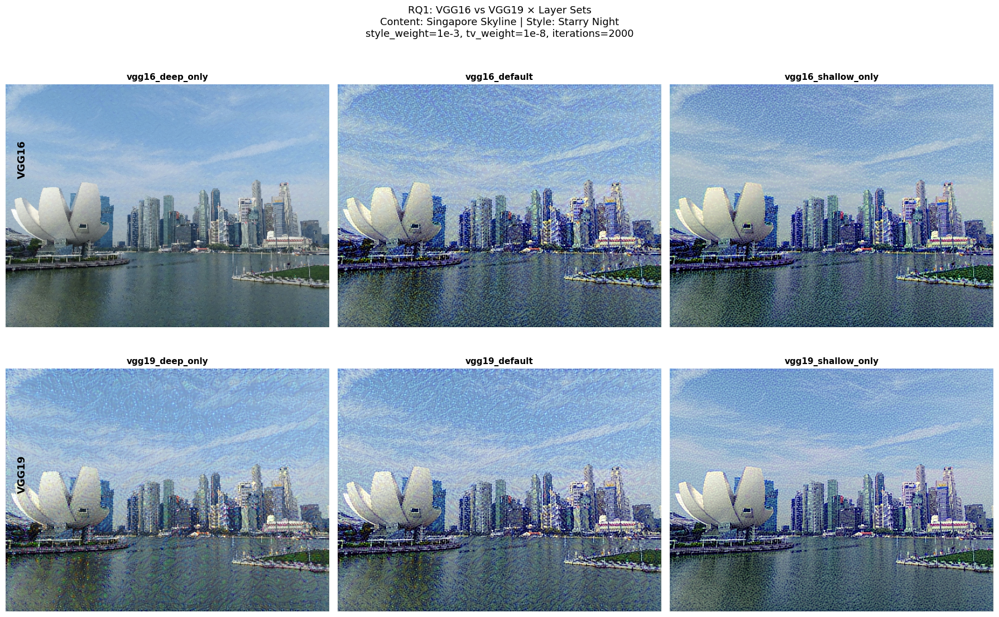

Saved to: /content/gdrive/MyDrive/NST_FYP/figures/rq1_visual_comparison.png


In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

rq1_dir = os.path.join(PROJECT_ROOT, "results/rq1_backbone")

# Only it2000 files with new image
images = sorted([f for f in os.listdir(rq1_dir)
                 if f.endswith('.png')
                 and 'singapore' in f
                 and 'it2000' in f])

print(f"Found {len(images)} images:")
for f in images:
    print(f" - {f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, fname in enumerate(images):
    img = mpimg.imread(os.path.join(rq1_dir, fname))
    axes[idx].imshow(img)
    title = fname.replace('_singapore_starrynight_it2000.png', '')
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

# Add row labels
fig.text(0.02, 0.75, 'VGG16', fontsize=13,
         fontweight='bold', rotation=90, va='center')
fig.text(0.02, 0.28, 'VGG19', fontsize=13,
         fontweight='bold', rotation=90, va='center')

fig.suptitle('RQ1: VGG16 vs VGG19 × Layer Sets\n'
             'Content: Singapore Skyline | Style: Starry Night\n'
             'style_weight=1e-3, tv_weight=1e-8, iterations=2000',
             fontsize=13)
plt.tight_layout()

save_path = os.path.join(PROJECT_ROOT, 'figures/rq1_visual_comparison.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [46]:
import pandas as pd

df = pd.read_csv(results_log_path)
rq1 = df[df["rq"] == "rq1_backbone"]

print("RQ1 Results Summary:")
print("="*70)
print(rq1[["backbone", "layer_set",
           "final_content_loss",
           "final_style_loss",
           "final_tv_loss",
           "final_total_loss",
           "wall_clock_seconds",
           "ssim_content_output"]].to_string(index=False))
print("="*70)

RQ1 Results Summary:
backbone    layer_set  final_content_loss  final_style_loss  final_tv_loss  final_total_loss  wall_clock_seconds  ssim_content_output
   vgg16      default            3.785510        288.587433     107.152458        399.525421          427.785080             0.635473
   vgg16 shallow_only            3.071998        336.781250     108.207474        448.060730          396.767620             0.674477
   vgg16    deep_only            0.649833         30.826574      33.113373         64.589783          361.330667             0.984666
   vgg19      default           12.146661        182.731476     109.270752        304.148895          500.739375             0.616072
   vgg19 shallow_only            5.859350        274.860779     110.149727        390.869843          469.922263             0.660065
   vgg19    deep_only           14.222111         47.514698      64.167931        125.904739          436.677630             0.699851


## 19. RQ2 Real Sweep
Runs 6 configs varying style weight (4 values) and
TV weight (2 values) on VGG19/default. Results
saved to Drive and logged to `results_log.csv`.

In [47]:
rq2_configs = build_rq2_configs(DEFAULT_CONFIG)
print(f"RQ2: {len(rq2_configs)} configs")
for c in rq2_configs:
    print(f"  sw={c['style_weight']:.0e} "
          f"tv={c['total_variation_weight']:.0e}")
run_sweep(rq2_configs, results_log_path)
print("RQ2 COMPLETE")

RQ2: 6 configs
  sw=1e-04 tv=1e-08
  sw=1e-03 tv=1e-08
  sw=1e-02 tv=1e-08
  sw=1e-01 tv=1e-08
  sw=1e-03 tv=1e-09
  sw=1e-03 tv=1e-07
Running 1 of 6: rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-04_tv1.0e-08_it2000
[done] rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-04_tv1.0e-08_it2000 — total_loss=242.40, 500.9s
Running 2 of 6: rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=304.15, 499.4s
Running 3 of 6: rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-02_tv1.0e-08_it2000
[done] rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-02_tv1.0e-08_it2000 — total_loss=596.51, 501.0s
Running 4 of 6: rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-01_tv1.0e-08_it2000
[done] rq2_weights_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.

In [49]:
import pandas as pd
df = pd.read_csv(results_log_path)
rq2 = df[df["rq"] == "rq2_weights"]
print(rq2[["style_weight", "tv_weight",
           "final_content_loss", "final_style_loss",
           "final_tv_loss", "final_total_loss",
           "ssim_content_output"]].to_string(index=False))

 style_weight    tv_weight  final_content_loss  final_style_loss  final_tv_loss  final_total_loss  ssim_content_output
       0.0001 1.000000e-08            7.073305        173.045975      62.285149        242.404419             0.821241
       0.0010 1.000000e-08           12.144216        182.735535     109.269432        304.149170             0.616065
       0.0100 1.000000e-08           17.700666        470.393372     108.413033        596.507080             0.604356
       0.1000 1.000000e-08           23.708153        444.250336     108.868004        576.826477             0.474480
       0.0010 1.000000e-09           12.152175        182.681961      12.519197        207.353333             0.624420
       0.0010 1.000000e-07           12.775167        252.675201     562.030701        827.481079             0.556365


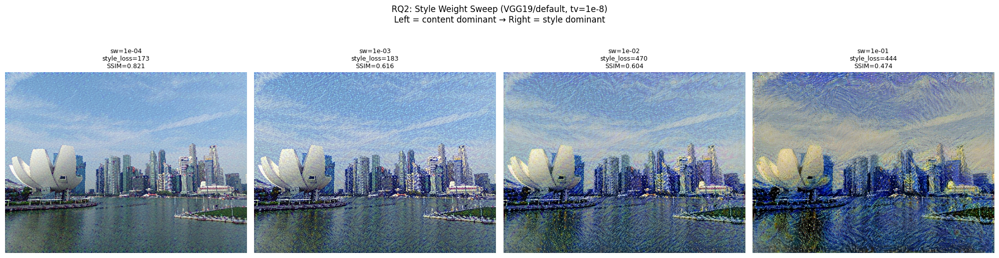

Saved: /content/gdrive/MyDrive/NST_FYP/figures/rq2_style_weight_sweep.png


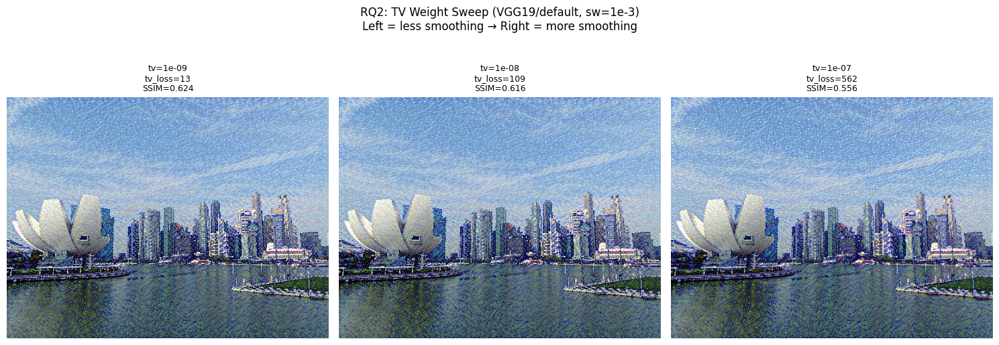

Saved: /content/gdrive/MyDrive/NST_FYP/figures/rq2_tv_weight_sweep.png


In [52]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import pandas as pd

# Get RQ2 results ordered by style_weight
df = pd.read_csv(results_log_path)
rq2 = df[df["rq"] == "rq2_weights"].copy()

# Separate style sweep and tv sweep
style_sweep = rq2[rq2["tv_weight"] == 1e-8].sort_values("style_weight")
tv_sweep = rq2[rq2["style_weight"] == 1e-3].sort_values("tv_weight")

# ── Figure 1: Style weight sweep ──
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 6))

for idx, (_, row) in enumerate(style_sweep.iterrows()):
    img = mpimg.imread(row["output_path"])
    axes1[idx].imshow(img)
    axes1[idx].set_title(
        f"sw={row['style_weight']:.0e}\n"
        f"style_loss={row['final_style_loss']:.0f}\n"
        f"SSIM={row['ssim_content_output']:.3f}",
        fontsize=9)
    axes1[idx].axis('off')

fig1.suptitle(
    'RQ2: Style Weight Sweep (VGG19/default, tv=1e-8)\n'
    'Left = content dominant → Right = style dominant',
    fontsize=12)
plt.tight_layout()
path1 = os.path.join(PROJECT_ROOT, 'figures/rq2_style_weight_sweep.png')
plt.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path1}")

# ── Figure 2: TV weight sweep ──
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6))

for idx, (_, row) in enumerate(tv_sweep.iterrows()):
    img = mpimg.imread(row["output_path"])
    axes2[idx].imshow(img)
    axes2[idx].set_title(
        f"tv={row['tv_weight']:.0e}\n"
        f"tv_loss={row['final_tv_loss']:.0f}\n"
        f"SSIM={row['ssim_content_output']:.3f}",
        fontsize=9)
    axes2[idx].axis('off')

fig2.suptitle(
    'RQ2: TV Weight Sweep (VGG19/default, sw=1e-3)\n'
    'Left = less smoothing → Right = more smoothing',
    fontsize=12)
plt.tight_layout()
path2 = os.path.join(PROJECT_ROOT, 'figures/rq2_tv_weight_sweep.png')
plt.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path2}")

## 20. Adam LR Calibration on Real Images
Calibrates the Adam learning rate against the real
images at full resolution before RQ3 runs. The value
set here is the one Adam uses in the optimiser
comparison that follows.

In [54]:
import math
_calibration_results, _chosen_adam_lr = calibrate_adam_lr(DEFAULT_CONFIG)
print(f"\nOPTIMIZER_CONFIGS['adam']['learning_rate'] = {OPTIMIZER_CONFIGS['adam']['learning_rate']}")

lr=0.01: final_total_loss=5690.13
lr=0.1: final_total_loss=4027.28
lr=1.0: final_total_loss=390.38
lr=10.0: final_total_loss=131.77

Best lr=10.0 (final_total_loss=131.77) -> OPTIMIZER_CONFIGS['adam']['learning_rate'] updated.

OPTIMIZER_CONFIGS['adam']['learning_rate'] = 10.0


## 21. RQ3 Real Sweep
Runs 2 configurations, SGD and Adam, on VGG19/default
with calibrated optimiser settings. Results are saved
to Drive and logged to `results_log.csv`.

In [55]:
rq3_configs = build_rq3_configs(DEFAULT_CONFIG)
print(f"RQ3: {len(rq3_configs)} configs")
run_sweep(rq3_configs, results_log_path)
print("RQ3 COMPLETE")

RQ3: 2 configs
Running 1 of 2: rq3_optimizer_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] rq3_optimizer_vgg19_default_sgd_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=304.15, 501.5s
Running 2 of 2: rq3_optimizer_vgg19_default_adam_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] rq3_optimizer_vgg19_default_adam_singapore_starrynight_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=72.07, 501.2s
Sweep pass complete.
RQ3 COMPLETE


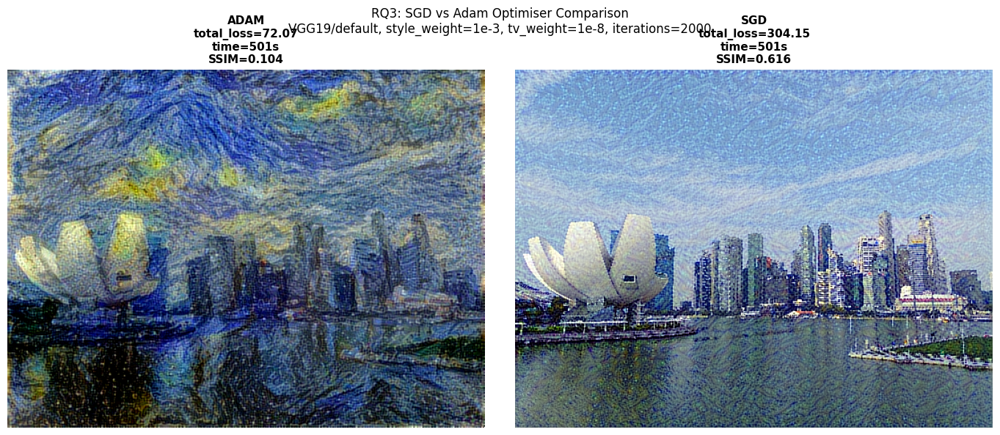

Saved: /content/gdrive/MyDrive/NST_FYP/figures/rq3_optimizer_comparison.png


In [56]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os

df = pd.read_csv(results_log_path)
rq3 = df[df["rq"] == "rq3_optimizer"].sort_values("optimizer_name")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (_, row) in enumerate(rq3.iterrows()):
    img = mpimg.imread(row["output_path"])
    axes[idx].imshow(img)
    axes[idx].set_title(
        f"{row['optimizer_name'].upper()}\n"
        f"total_loss={row['final_total_loss']:.2f}\n"
        f"time={row['wall_clock_seconds']:.0f}s\n"
        f"SSIM={row['ssim_content_output']:.3f}",
        fontsize=11, fontweight='bold')
    axes[idx].axis('off')

fig.suptitle(
    'RQ3: SGD vs Adam Optimiser Comparison\n'
    'VGG19/default, style_weight=1e-3, tv_weight=1e-8, '
    'iterations=2000',
    fontsize=12)
plt.tight_layout()

save_path = os.path.join(PROJECT_ROOT,
                          'figures/rq3_optimizer_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## 22. Gallery Real Sweep
Runs 6 configurations across 3 content images and 2
style images, using the configuration carried forward
from RQ1, RQ2 and RQ3. Requires all gallery images to
be present in Drive before running.

In [69]:
gallery_configs = build_gallery_configs(DEFAULT_CONFIG)
print(f"Gallery: {len(gallery_configs)} configs")
run_sweep(gallery_configs, results_log_path)
print("GALLERY COMPLETE")

Gallery: 6 configs
Running 1 of 6: gallery_vgg19_default_sgd_content1_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] gallery_vgg19_default_sgd_content1_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=459.53, 427.1s
Running 2 of 6: gallery_vgg19_default_sgd_content1_style2_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] gallery_vgg19_default_sgd_content1_style2_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=260.75, 426.8s
Running 3 of 6: gallery_vgg19_default_sgd_content2_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000
[done] gallery_vgg19_default_sgd_content2_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=1082.04, 245.1s
[skip] gallery_vgg19_default_sgd_content2_style2_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — already completed
Running 5 of 6: gallery_vgg19_default_sgd_content3_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (142498944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[done] gallery_vgg19_default_sgd_content3_style1_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — total_loss=660.64, 296.2s
[skip] gallery_vgg19_default_sgd_content3_style2_cw2.5e-08_sw1.0e-03_tv1.0e-08_it2000 — already completed
Sweep pass complete.
GALLERY COMPLETE


In [70]:
import pandas as pd
df = pd.read_csv(results_log_path)
gallery = df[df["rq"] == "gallery"]
print(f"Gallery rows: {len(gallery)}")
print(gallery[["content_image", "style_image",
               "final_total_loss",
               "ssim_content_output"]].to_string(index=False))

Gallery rows: 6
content_image style_image  final_total_loss  ssim_content_output
     content2      style2        110.635086             0.640926
     content3      style2        264.276794             0.891455
     content1      style1        459.529053             0.557583
     content1      style2        260.752686             0.659743
     content2      style1       1082.042603             0.434365
     content3      style1        660.635132             0.649042


Gallery rows: 6
content_image style_image  final_total_loss  ssim_content_output
     content2      style2        110.635086             0.640926
     content3      style2        264.276794             0.891455
     content1      style1        459.529053             0.557583
     content1      style2        260.752686             0.659743
     content2      style1       1082.042603             0.434365
     content3      style1        660.635132             0.649042


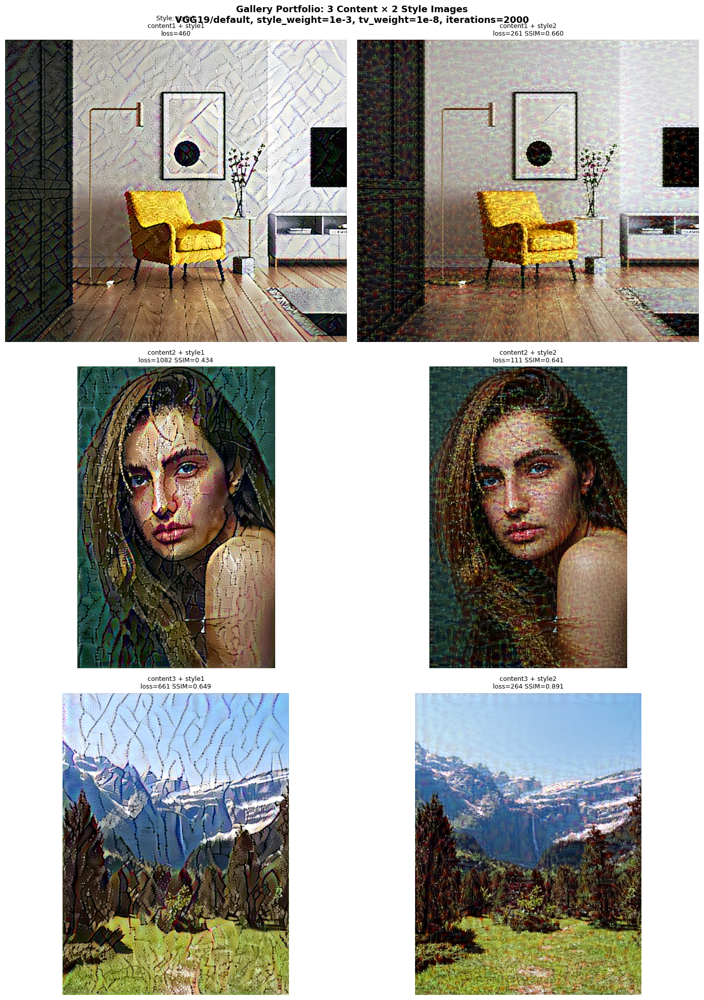


Saved: /content/gdrive/MyDrive/NST_FYP/figures/gallery_portfolio.png


In [71]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os

df = pd.read_csv(results_log_path)
gallery = df[df["rq"] == "gallery"].copy()

print(f"Gallery rows: {len(gallery)}")
print(gallery[["content_image", "style_image",
               "final_total_loss",
               "ssim_content_output"]].to_string(index=False))

content_ids = ["content1", "content2", "content3"]
style_ids = ["style1", "style2"]

fig, axes = plt.subplots(3, 2, figsize=(14, 20))

for row, content_id in enumerate(content_ids):
    for col, style_id in enumerate(style_ids):
        ax = axes[row][col]
        match = gallery[
            (gallery["content_image"] == content_id) &
            (gallery["style_image"] == style_id)
        ]
        if not match.empty:
            img_path = match.iloc[0]["output_path"]
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                ax.imshow(img)
                ssim = match.iloc[0]["ssim_content_output"]
                loss = match.iloc[0]["final_total_loss"]
                ax.set_title(
                    f"{content_id} + {style_id}\n"
                    f"loss={loss:.0f} SSIM={ssim:.3f}",
                    fontsize=9)
            else:
                ax.text(0.5, 0.5, "Image not found\n"
                       f"{img_path}",
                       ha="center", va="center",
                       fontsize=8, color="red")
        else:
            ax.text(0.5, 0.5, "No result logged",
                   ha="center", va="center",
                   fontsize=9, color="orange")
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(content_id, fontsize=11,
                         fontweight='bold')

# Column headers for style images
axes[0][0].set_title(f"Style: style1\n"
                     f"content1 + style1\n"
                     f"loss={gallery[(gallery['content_image']=='content1') & (gallery['style_image']=='style1')]['final_total_loss'].values[0]:.0f}",
                     fontsize=9)

fig.suptitle(
    'Gallery Portfolio: 3 Content × 2 Style Images\n'
    'VGG19/default, style_weight=1e-3, '
    'tv_weight=1e-8, iterations=2000',
    fontsize=13, fontweight='bold')

plt.tight_layout()

save_path = os.path.join(PROJECT_ROOT,
                         'figures/gallery_portfolio.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {save_path}")